# Project Work NLP: Analisi della Distorsione e Omogeneizzazione della Scrittura da parte degli LLM

Questo notebook esplora l'impatto dei Modelli Linguistici di Grandi Dimensioni (LLM) sulla scrittura umana, implementando un'analisi basata su due recenti studi:

1. L'analisi di *"How LLMs Distort Our Written Language"* (2026), che dimostra come l'uso dell'IA come co-pilota di scrittura tenda a cancellare l'identità dell'autore, generando una "voce algoritmica" omogeneizzata.
2. L'indagine di *"Scientific production in the era of large language models"* (Science, 2025), che evidenzia come l'IA alteri la complessità linguistica spingendo verso un linguaggio iper-formale e artificiale.

Al fine di approfondire sperimentalmente i risultati emersi, questo project work è organizzato in tre esperimenti, ognuno dedicato all'analisi di uno specifico effetto degli LLM sulla produzione testuale.

* **Esperimento 1 - Entropia, Perplessità, Burstiness e Leggebilità:** Analisi di come varia la prevedibilità statistica e la complessità strutturale del testo passando dalla bozza umana iniziale, alla revisione manuale, fino alla revisione artificiale (utilizzando il dataset *ArgRewrite*).
* **Esperimento 2 - Classificazione con BERT:** Addestramento di un modello Transformer (*DistilBERT*) per verificare se le firme stilistiche lasciate dall'IA sono sufficientemente marcate da essere distinte in un task di classificazione multiclasse.
* **Esperimento 3 - Collasso della Diversità Lessicale:** Replicazione della metodologia applicata alle recensioni *ICLR 2026* per misurare la perdita di varietà del vocabolario (tramite Type-Token Ratio) confrontando testi puramente umani e testi generati da IA su un dataset indipendente.

---

### Configurazione dell'Ambiente e Importazione delle Librerie
In questa cella viene configurato l'ambiente importando i pacchetti necessari per la manipolazione dei dati (`pandas`, `numpy`), la visualizzazione grafica (`matplotlib`, `seaborn`) e il calcolo delle metriche linguistiche avanzate (`transformers`, `nltk`, `textstat`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import nltk
import textstat
from IPython.display import display, Markdown

# download dei tokenizzatori NLTK per dividere il testo in frasi e parole
nltk.download('punkt')
nltk.download('punkt_tab')

# setup grafico per le curve evolutive temporali
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Caricamento dei Dati

Prima di estrarre le metriche linguistiche, strutturiamo il dataset in modo da allineare ogni singolo saggio lungo il suo ciclo vitale. 

Attraverso l'integrazione del corpus **ArgRewrite V.2** (per i testi umani) e delle riscritture contenute in `dataframe_essays_llm_model.csv` (per i modelli generativi), costruiamo un unico DataFrame unificato (`df_timeline`). 

Ogni riga del DataFrame rappresenta un saggio tracciato in tre momenti storici:
1. **$t_0$ - Bozza Iniziale**: Il testo grezzo scritto dallo studente prima di ricevere feedback (`Draft1`).
2. **$t_1$ - Revisione Umana**: L'evoluzione naturale del saggio rivista dallo studente a seguito dei commenti (`Draft2`).
3. **$t_1^*$ - Riscrittura IA**: La revisione parallela generata dall'LLM di riferimento a partire dalla bozza $t_0$ e dal feedback.

Questo allineamento ci permetterà di confrontare direttamente la traiettoria evolutiva dell'apprendimento umano contro la traiettoria di riscrittura dell'IA.

In [2]:
PATH_ANALYSIS = "./data/argrewrite_analysis"
csv_real_path = os.path.join(PATH_ANALYSIS, "dataframe_essays_llm_model.csv")

if os.path.exists(csv_real_path):
    df_raw = pd.read_csv(csv_real_path)
    
    modelli_disponibili = df_raw["llm_model"].unique()

    print(f"[DATA] Modelli LLM presenti nel dataset: {list(modelli_disponibili)}")

    # selezioniamo il primo modello LLM disponibile
    modello_target = modelli_disponibili[0]
    
    df_filtered = df_raw[df_raw["llm_model"] == modello_target].copy()
    
    # costruzione del DataFrame timeline
    df_timeline = pd.DataFrame({
        "essay_id": df_filtered["essay_id"],
        "t0_bozza": df_filtered["draft1"],
        "t1_umano": df_filtered["draft2"],
        "t1_ia": df_filtered["ai_text"],
        "llm_model": df_filtered["llm_model"]
    }).dropna().reset_index(drop=True)
    
    print(f"[DATA] Caricamento completato con il modello: '{modello_target}'")
    print(f"[DATA] Totale saggi caricati lungo la timeline: {len(df_timeline)}")
else:
    raise FileNotFoundError(f"Impossibile trovare il file: {csv_real_path}")

[DATA] Modelli LLM presenti nel dataset: ['CLAUDE-HAIKU-4-5-20251001', 'GPT-5-MINI', 'GEMINI-2.5-FLASH']
[DATA] Caricamento completato con il modello: 'CLAUDE-HAIKU-4-5-20251001'
[DATA] Totale saggi caricati lungo la timeline: 860


---

## Esperimento 1 - Evoluzione Temporale delle Metriche Linguistiche

### Obiettivo
In questo primo esperimento vogliamo misurare come si trasforma l'impronta stilistica di un testo durante il suo processo di revisione. La letteratura scientifica suggerisce che l'intervento di un LLM tenda ad "appiattire" il testo, rendendolo statisticamente più prevedibile e strutturalmente monotono, aumentandone però al contempo la complessità del vocabolario.

Per dimostrarlo, analizzeremo l'evoluzione delle grandezze testuali confrontando tre fasi temporali distinte:
1. **$t_0$ - Bozza Iniziale:** Il saggio originale scritto dallo studente.
2. **$t_1$ - Revisione Manuale:** Il saggio corretto dallo studente seguendo il feedback del docente.
3. **$t_1^*$ - Riscrittura IA:** Il saggio originale fatto correggere a un modello IA utilizzando lo stesso feedback.

### Metriche Calcolate
Per tracciare questa evoluzione estrarremo quattro grandezze fondamentali:

* **Entropia (Cross-Entropy Loss):** Misura il grado di incertezza del modello nel prevedere la parola successiva. Testi molto "standardizzati" dall'IA presentano un'entropia minore.
* **Perplessità:** Direttamente derivata dall'entropia, indica quanto il testo sia "sorprendente" per un modello linguistico. Viene calcolata esponenzialmente:
  $$Perplexity = \exp(Entropy)$$
* **Burstiness:** Valuta la varianza nella lunghezza delle frasi. Gli esseri umani alternano frasi brevi e lunghe (valore alto burstiness), mentre l'IA tende a produrre frasi di lunghezza uniforme. La calcoleremo tramite la deviazione standard del numero di parole per frase.
* **Leggibilità Flesch:** Un indice per quantificare la difficoltà di lettura. L'obiettivo è verificare se la revisione dell'IA introduca una complessità sintattica artificiale rispetto alla revisione umana.

### Estrattore Metriche Linguistiche

In [3]:
# pulizia della VRAM
torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("=" * 70)
print("CALCOLO DELLE METRICHE LINGUISTICHE")
print("=" * 70)
print(f"Dispositivo: {device.upper()}")
print(f"Testi da analizzare: {len(df_timeline)}")
print("-" * 70)

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model.eval()

def calcola_entropia_perplessita(testo):
    """Calcola Loss e Perplexity con GPT-2."""
    if not isinstance(testo, str) or not testo.strip():
        return np.nan, np.nan
    
    inputs = tokenizer(testo, return_tensors="pt", truncation=True, max_length=512).to(device)
    
    if inputs.input_ids.shape[1] < 2:
        return np.nan, np.nan
        
    with torch.no_grad():
        outputs = model(inputs.input_ids, labels=inputs.input_ids)
        loss = outputs.loss.item()
        perplexity = float(np.exp(loss))
        
    return loss, perplexity

stadi = [("t0", "t0_bozza", "t₀ Bozza Umana"), ("t1_h", "t1_umano", "t₁ Revisione Umana"), ("t1_ai", "t1_ia", "t₁* Riscrittura IA")]

for prefisso, col_testo, nome_stadio in stadi:
    print(f"\n[{nome_stadio}]")
    print("-" * 70)
    
    entropie, perplessita, burstiness, leggibilita = [], [], [], []
    
    totale = len(df_timeline)
    
    for i, testo in enumerate(df_timeline[col_testo], start=1):
        
        # 1. GPT-2 su GPU
        e, p = calcola_entropia_perplessita(testo)
        
        # 2. NLTK e Textstat su CPU
        if isinstance(testo, str) and testo.strip():
            frasi = nltk.sent_tokenize(testo)
            b = (float(np.std([len(nltk.word_tokenize(f)) for f in frasi])) if len(frasi) > 1 else 0.0)
            l = textstat.flesch_reading_ease(testo)
        else:
            b, l = 0.0, np.nan
            
        entropie.append(e)
        perplessita.append(p)
        burstiness.append(b)
        leggibilita.append(l)
        
        # avanzamento ogni 10 testi
        if i % 10 == 0 or i == totale:
            print(f"  Progressione: {i:>3}/{totale} ({i/totale*100:5.1f}%)", end="\r")
    
    df_timeline[f"{prefisso}_entropy"] = entropie
    df_timeline[f"{prefisso}_perplexity"] = perplessita
    df_timeline[f"{prefisso}_burstiness"] = burstiness
    df_timeline[f"{prefisso}_readability"] = leggibilita
    
    # riepilogo stadio
    print(f"\n  ✓ Completato")
    print(f"    Entropia:    {np.nanmean(entropie):.3f}")
    print(f"    Perplexity:  {np.nanmean(perplessita):.3f}")
    print(f"    Burstiness:  {np.nanmean(burstiness):.3f}")
    print(f"    Flesch:      {np.nanmean(leggibilita):.3f}")


# pulizia finale VRAM
torch.cuda.empty_cache()

print("\n" + "=" * 70)
print("CALCOLO COMPLETATO CON SUCCESSO")
print("=" * 70)

print("\nAnteprima Perplexity:")
print(df_timeline[["essay_id", "t0_perplexity", "t1_h_perplexity", "t1_ai_perplexity"]].head().to_string(index=False))

CALCOLO DELLE METRICHE LINGUISTICHE
Dispositivo: CUDA
Testi da analizzare: 860
----------------------------------------------------------------------


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


[t₀ Bozza Umana]
----------------------------------------------------------------------


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Progressione: 860/860 (100.0%)
  ✓ Completato
    Entropia:    3.182
    Perplexity:  25.185
    Burstiness:  10.281
    Flesch:      47.094

[t₁ Revisione Umana]
----------------------------------------------------------------------
  Progressione: 860/860 (100.0%)
  ✓ Completato
    Entropia:    3.146
    Perplexity:  24.212
    Burstiness:  10.007
    Flesch:      46.142

[t₁* Riscrittura IA]
----------------------------------------------------------------------
  Progressione: 860/860 (100.0%)
  ✓ Completato
    Entropia:    3.032
    Perplexity:  21.248
    Burstiness:  8.489
    Flesch:      21.413

CALCOLO COMPLETATO CON SUCCESSO

Anteprima Perplexity:
 essay_id  t0_perplexity  t1_h_perplexity  t1_ai_perplexity
        1      21.090680        22.212243         14.772194
        2      22.977983        20.354880         19.025180
        3      28.630659        29.665382         24.515809
        4      23.649038        19.020603         16.443756
        5      21.972151      

### Visualizzazione Grafica comparativa

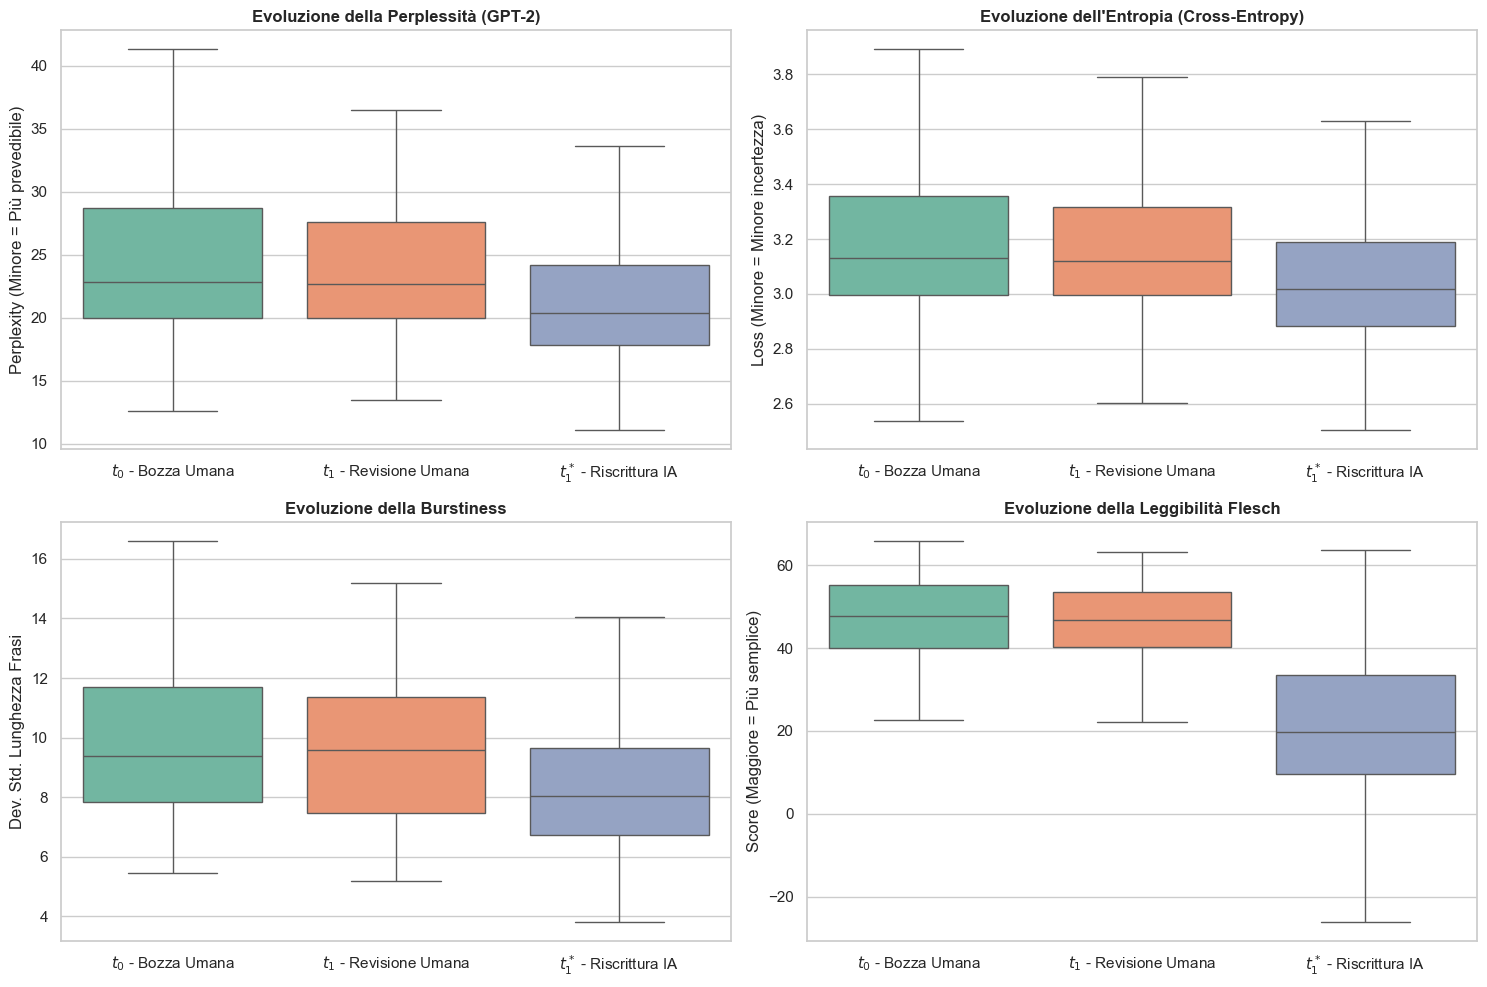

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metriche_config = [
    ("perplexity", "Evoluzione della Perplessità (GPT-2)", "Perplexity (Minore = Più prevedibile)", axes[0, 0]),
    ("entropy", "Evoluzione dell'Entropia (Cross-Entropy)", "Loss (Minore = Minore incertezza)", axes[0, 1]),
    ("burstiness", "Evoluzione della Burstiness", "Dev. Std. Lunghezza Frasi", axes[1, 0]),
    ("readability", "Evoluzione della Leggibilità Flesch", "Score (Maggiore = Più semplice)", axes[1, 1])
]

for col, titolo, ylabel, ax in metriche_config:
    df_melt = pd.melt(
        df_timeline, 
        value_vars=[f"t0_{col}", f"t1_h_{col}", f"t1_ai_{col}"],
        var_name="Stadio", value_name="Valore"
    )
    df_melt["Stadio"] = df_melt["Stadio"].map({
        f"t0_{col}": "$t_0$ - Bozza Umana",
        f"t1_h_{col}": "$t_1$ - Revisione Umana",
        f"t1_ai_{col}": "$t_1^*$ - Riscrittura IA"
    })
    
    sns.boxplot(
        data=df_melt, x="Stadio", y="Valore", ax=ax, 
        hue="Stadio", palette="Set2", legend=False, showfliers=False
    )
    ax.set_title(titolo, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()


**Risultati del Grafico**

I quattro boxplot evidenziano una netta divergenza tra la revisione umana ($t_1$) e la riscrittura generata dall'IA ($t_1^*$): mentre la correzione umana conserva la struttura e le metriche della bozza originale ($t_0$), l'intervento del modello altera significativamente l'impronta stilometrica del testo.

* **Perplessità ed Entropia:** La riscrittura $t_1^*$ mostra una contrazione verso il basso della mediana e dell'intervallo interquartile. La diminuzione della perplessità e della loss indica che il testo dell'IA diventa statisticamente più prevedibile e uniforme rispetto alle bozze umane.
* **Burstiness:** La deviazione standard della lunghezza delle frasi diminuisce sensibilmente in $t_1^*$, evidenziando una struttura sintattica più omogenea e priva della naturale variabilità ritmica che caratterizza sia $t_0$ sia $t_1$.
* **Leggibilità Flesch:** Si osserva il calo più drastico dove il punteggio medio crolla da circa 48 ($t_0$ e $t_1$) a circa 20 ($t_1^*$). L'IA sposta forzatamente il testo verso un registro nettamente più complesso e iper-formale.

I dati confermano che la riscrittura sintetica non si limita a rifinire il testo, ma ne appiattisce la variabilità ritmico-statistica e ne appesantisce la struttura linguistica.

### Tabella Riassuntiva delle Medie e Deviazioni Standard

In [6]:
metriche_summary = {
    "Stadio": ["$t_0$ - Bozza Umana", "$t_1$ - Revisione Umana", "$t_1^*$ - Riscrittura IA"],
    "Entropy (Media ± Std)": [
        f"{df_timeline['t0_entropy'].mean():.2f} ± {df_timeline['t0_entropy'].std():.2f}",
        f"{df_timeline['t1_h_entropy'].mean():.2f} ± {df_timeline['t1_h_entropy'].std():.2f}",
        f"{df_timeline['t1_ai_entropy'].mean():.2f} ± {df_timeline['t1_ai_entropy'].std():.2f}"
    ],
    "Perplexity (Media ± Std)": [
        f"{df_timeline['t0_perplexity'].mean():.2f} ± {df_timeline['t0_perplexity'].std():.2f}",
        f"{df_timeline['t1_h_perplexity'].mean():.2f} ± {df_timeline['t1_h_perplexity'].std():.2f}",
        f"{df_timeline['t1_ai_perplexity'].mean():.2f} ± {df_timeline['t1_ai_perplexity'].std():.2f}"
    ],
    "Burstiness (Media ± Std)": [
        f"{df_timeline['t0_burstiness'].mean():.2f} ± {df_timeline['t0_burstiness'].std():.2f}",
        f"{df_timeline['t1_h_burstiness'].mean():.2f} ± {df_timeline['t1_h_burstiness'].std():.2f}",
        f"{df_timeline['t1_ai_burstiness'].mean():.2f} ± {df_timeline['t1_ai_burstiness'].std():.2f}"
    ],
    "Leggibilità Flesch (Media ± Std)": [
        f"{df_timeline['t0_readability'].mean():.2f} ± {df_timeline['t0_readability'].std():.2f}",
        f"{df_timeline['t1_h_readability'].mean():.2f} ± {df_timeline['t1_h_readability'].std():.2f}",
        f"{df_timeline['t1_ai_readability'].mean():.2f} ± {df_timeline['t1_ai_readability'].std():.2f}"
    ]
}

df_summary = pd.DataFrame(metriche_summary)
display(Markdown(df_summary.to_markdown(index=False)))

| Stadio                   | Entropy (Media ± Std)   | Perplexity (Media ± Std)   | Burstiness (Media ± Std)   | Leggibilità Flesch (Media ± Std)   |
|:-------------------------|:------------------------|:---------------------------|:---------------------------|:-----------------------------------|
| $t_0$ - Bozza Umana      | 3.18 ± 0.29             | 25.18 ± 8.08               | 10.28 ± 3.33               | 47.09 ± 9.70                       |
| $t_1$ - Revisione Umana  | 3.15 ± 0.28             | 24.21 ± 7.56               | 10.01 ± 3.40               | 46.14 ± 9.37                       |
| $t_1^*$ - Riscrittura IA | 3.03 ± 0.22             | 21.25 ± 4.83               | 8.49 ± 2.59                | 21.41 ± 16.29                      |

**Analisi della Tabella Riassuntiva**

I valori quantitativi sintetizzati nella tabella confermano con precisione numerica il comportamento osservato nei grafici:

* **Stabilità della Revisione Umana ($t_0 \rightarrow t_1$):** Il passaggio dalla bozza iniziale alla revisione umana mostra variazioni limitate in tutte le metriche considerate. La perplexity passa da $25.18$ a $24.21$, l’entropia da $3.18$ a $3.15$, la burstiness da $10.28$ a $10.01$ e il punteggio della leggibilità flesch da $47.09$ a $46.14$. Nel complesso, la revisione umana mantiene quindi caratteristiche statistiche simili a quelle della bozza originale.
* **Contrazione delle Metriche con l'IA ($t1^*$):** La riscrittura con IA presenta una riduzione rispetto alla bozza iniziale in tutte le metriche considerate. L’entropia passa da $3.18$ a $3.03$, la perplexity da $25.18$ a $21.25$ e la burstiness da $10.28$ a $8.49$. La riduzione di entropia e perplexity indica una maggiore prevedibilità del testo secondo GPT-2, mentre la diminuzione della burstiness indica una minore variabilità nella lunghezza delle frasi.
* **Crollo dell'Indice Leggibilità Flesch:** La leggibilità registra il divario più marcato, crollando a $21.41 \pm 16.29$ rispetto al $\sim 46-47$ dei testi umani, confermando la tendenza dell'LLM a strutturare frasi significativamente più complesse e formalmente sovraccariche.

### Conclusioni Esperimento 1

L'analisi degli 860 saggi mostra una differenza evidente tra la revisione fatta dagli studenti e quella generata dall'IA. In particolare, mentre la revisione umana mantiene abbastanza stabili le caratteristiche del testo originale, la riscrittura IA porta a cambiamenti più marcati nelle metriche considerate.

- **Stabilità della revisione umana ($t_0 \rightarrow t_1$):** Il passaggio dalla bozza iniziale alla revisione dello studente porta a cambiamenti piuttosto limitati. Entropia, perplexity e burstiness rimangono infatti molto vicine ai valori iniziali, così come il punteggio della leggibilità flesch. Questo indica che la revisione umana modifica il testo senza cambiarne in modo significativo le caratteristiche statistiche e la struttura delle frasi.

- **Maggiore prevedibilità nella revisione IA ($t_0 \rightarrow t_1^*$):** La riscrittura effettuata dall'IA mostra invece una riduzione di entropia e perplexity, indicando che il testo risulta più prevedibile secondo GPT-2. Anche la burstiness diminuisce, mostrando una minore variabilità nella lunghezza delle frasi. Nel complesso, il testo generato dall'IA presenta quindi caratteristiche più uniformi rispetto alla versione originale e alla revisione umana.

- **Riduzione della leggibilità:** La differenza più evidente riguarda il punteggio flesch, che passa da $47.09$ nella bozza iniziale a $46.14$ nella revisione umana, mentre scende a $21.41$ nella riscrittura IA. Poiché valori più bassi indicano una minore facilità di lettura, questo risultato suggerisce che la riscrittura IA produca testi più complessi dal punto di vista della leggibilità.

In sintesi, la revisione umana mantiene abbastanza stabili le caratteristiche statistiche della bozza originale, mentre la riscrittura IA modifica maggiormente il testo, rendendolo più prevedibile, meno variabile nella struttura delle frasi. Queste differenze suggeriscono quindi che l'intervento dell'IA lasci una traccia stilistica riconoscibile nelle metriche analizzate.

Questi risultati forniscono la base per il passaggio all'**Esperimento 2**, in cui si verifica se le differenze osservate siano sufficienti per permettere a un classificatore automatico di distinguere le diverse tipologie e gli stadi dei testi.

   

---

## Esperimento 2 - Classificazione dello Stadio del Testo con DistilBERT

### Obiettivo

Nell'esperimento 1 abbiamo osservato che la revisione IA modifica alcune caratteristiche statistiche del testo rispetto alla revisione umana. In particolare, la riscrittura IA mostra una maggiore prevedibilità, una minore variabilità nella lunghezza delle frasi e una riduzione della leggibilità.

In questo secondo esperimento vogliamo verificare se queste differenze siano sufficientemente marcate da permettere a un modello di classificazione di distinguere automaticamente le diverse versioni dello stesso testo.

L'idea è quindi trasformare il problema in un task di **classificazione multiclasse**, in cui il modello deve riconoscere a quale dei tre stadi appartiene un testo:

1. **$t_0$ - Bozza iniziale:** testo originale scritto dallo studente.
2. **$t_1$ - Revisione umana:** testo modificato dallo studente dopo il feedback.
3. **$t_1^*$ - Revisione IA:** testo riscritto dall'LLM utilizzando lo stesso feedback.

Utilizzeremo **DistilBERT**, un modello Transformer pre-addestrato, che verrà fine-tuned sul nostro dataset per imparare a distinguere automaticamente queste tre categorie.

L'obiettivo finale è verificare se lo stile lasciato dalla revisione IA sia riconoscibile anche utilizzando direttamente il contenuto testuale, senza fornire al modello le metriche calcolate nell'Esperimento 1.

### Preparazione del Dataset

Per costruire il dataset di classificazione partiamo dal `df_timeline` utilizzato nell'Esperimento 1.

Ogni saggio contiene tre versioni dello stesso testo, ma per il classificatore queste versioni vengono trasformate in tre osservazioni separate.

In questo modo otteniamo una struttura del tipo:

| Testo | Classe |
|---|---|
| $t_0$ - Bozza iniziale | 0 |
| $t_1$ - Revisione umana | 1 |
| $t_1^*$ - Revisione IA | 2 |

La variabile target rappresenta quindi lo stadio del testo, mentre l'unica informazione fornita al modello è il testo stesso.

Il dataset finale viene successivamente diviso in **training set** e **test set**, mantenendo la stessa proporzione tra le tre classi.